In [1]:
#from a fieldmap in straight coordinates to one in curved coordinates
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s

(0.0, 1.0)

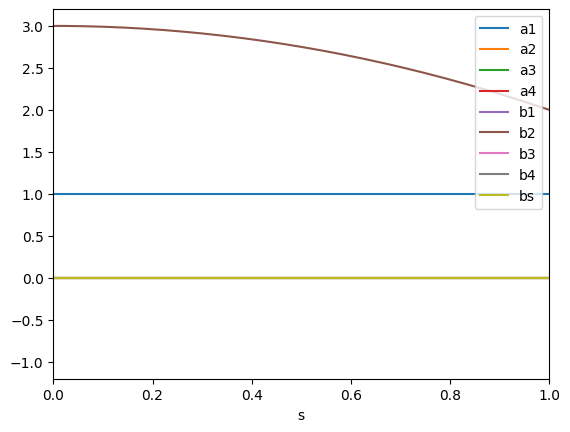

In [2]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [1, 0, 0, 0]
b_coeffs = [0,"-s**2+3",0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

Scalar potential phi(x,y,s): x*y**3/3 + x*y*(3 - s**2) + x
Scalar potential phi at (0.4,0.2,0.5): 0.6210666666666667


/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:96: UserWarning: The laplacian could not be evaluated
  warnings.warn("The laplacian could not be evaluated")


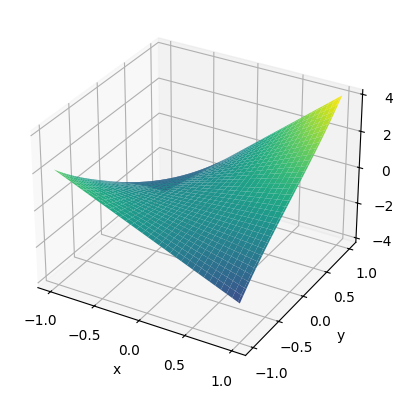

In [ ]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(0,1,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.5)#s=0.5 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [ ]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
#print("Bx shape:", Bx_ana.shape, "By shape:", By_ana.shape, "Bs shape:", Bs_ana.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
#print(xa.shape)

Bx shape: (101, 101, 101) By shape: (101, 101, 101) Bs shape: (101, 101, 101)
Data shape (N, 6): (1030301, 6)
(101,)


In [ ]:
rho = .5
phi = 0.5
xFS = np.linspace(-0.05, 0.05, 101)
yFS = np.linspace(-0.05, 0.05, 101)
sFS = np.linspace(-rho*phi, rho*phi, 101)

fm_fs = fm.calc_FS_coords(xFS, yFS, sFS, rho, phi, radius=0.01)

' \ndef fieldmap_to_grid(fm):\n    data = fm.get_data()\n    x = np.unique(data[:, 0])\n    y = np.unique(data[:, 1])\n    s = np.unique(data[:, 2])\n    order = np.lexsort((data[:, 2], data[:, 1], data[:, 0]))\n    data_sorted = data[order]\n    shape = (len(x), len(y), len(s))\n    Bx = data_sorted[:, 3].reshape(shape)\n    By = data_sorted[:, 4].reshape(shape)\n    Bs = data_sorted[:, 5].reshape(shape)\n    return x, y, s, Bx, By, Bs\n\nxFS_out, yFS_out, sFS_out, Bx_fs, By_fs, Bs_fs = fieldmap_to_grid(fm_fs)\n'

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:128: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


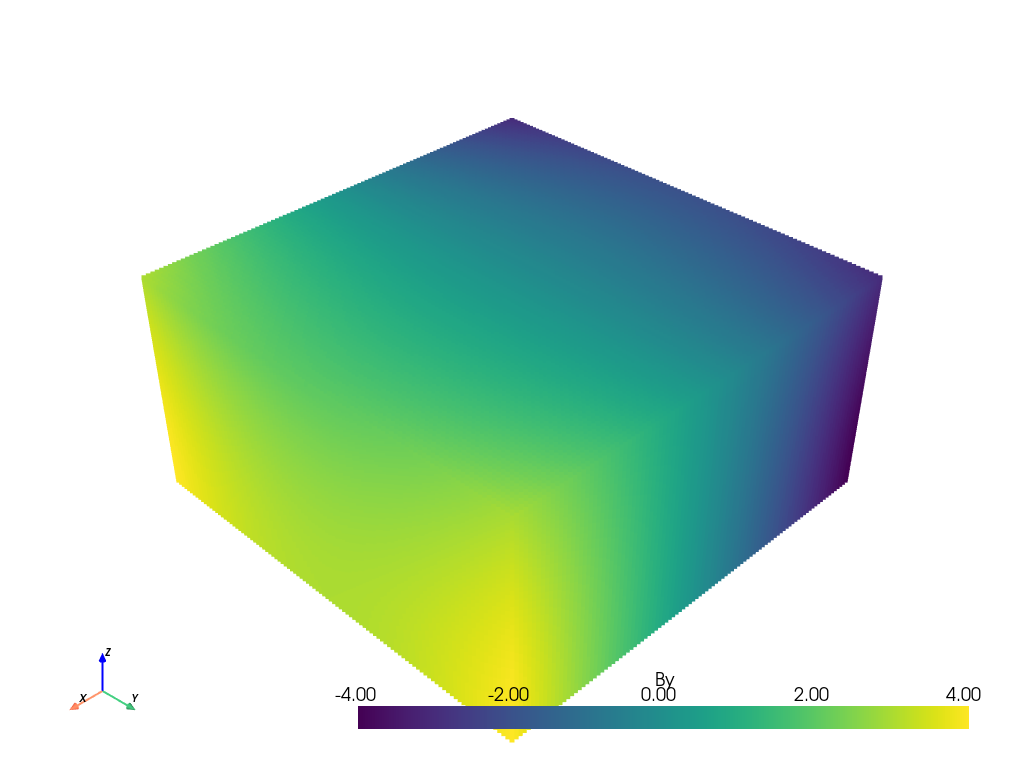

In [32]:
fm.plot(field="By")

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:128: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


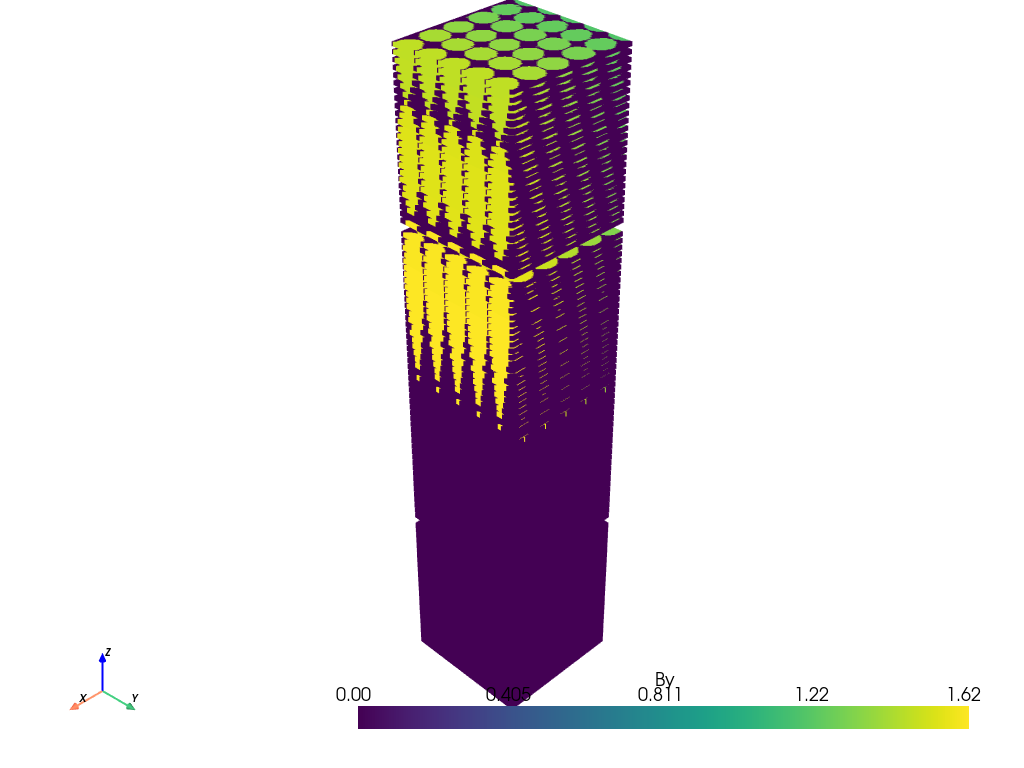

In [42]:
fm_fs.plot(field="By")

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:128: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


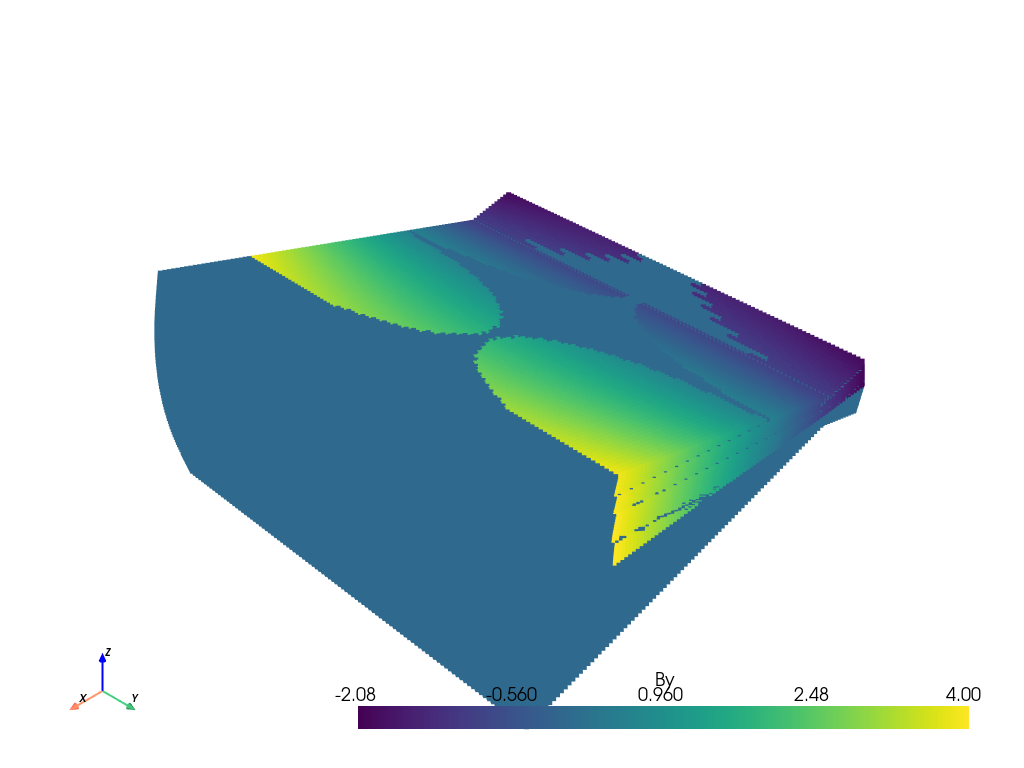

In [45]:
fm.FS_frame_plot(
    rho,
    phi,
    field="By",
    radius=0.01,#of interpolation
    xmax=1,
    ymax=1,
    nx=100,
    ny=100,
    ns=100
)